# **5. Baseline Modeling: Random Forest**

### **Environment Setup**

This notebook develops and evaluates a baseline Random Forest classifier for predicting ten-year coronary heart disease using the Framingham dataset. The modelling environment is configured by importing the required libraries and loading the prepared training and testing datasets for model development and evaluation.

### **Library Imports**

The required libraries are imported to support data manipulation, model development, and performance evaluation.

Imported and loaded saved splits 

In [1]:
# Import required libraries

import pandas as pd                  # Data manipulation and analysis
import numpy as np                   # Numerical computations
import matplotlib.pyplot as plt      # Data visualization
import seaborn as sns                # Statistical data visualization
import joblib                        # Saving and loading trained models

# Import the Random Forest classifier
from sklearn.ensemble import RandomForestClassifier    # Ensemble classification model

# Import evaluation metrics for model performance assessment
from sklearn.metrics import (
    accuracy_score,                  # Overall prediction accuracy
    precision_score,                 # Proportion of correctly predicted positive cases
    recall_score,                    # Ability to identify actual positive cases
    f1_score,                        # Harmonic mean of precision and recall
    roc_auc_score,                   # Area Under the ROC Curve
    classification_report,           # Detailed classification performance summary
    confusion_matrix,                # Confusion matrix for prediction outcomes
    roc_curve                        # Receiver Operating Characteristic curve
)

### **Data Ingestion**

The previously prepared training and testing datasets are loaded for Random Forest model development. Since Random Forest is a tree-based algorithm, feature standardization is not required, and the unscaled datasets are used directly.

In [2]:
# Load the unscaled training and testing datasets
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

# Display dataset dimensions
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3392, 15)
X_test shape: (848, 15)
y_train shape: (3392,)
y_test shape: (848,)


The prepared training and testing datasets were successfully loaded. The unscaled predictor variables were retained because Random Forest is not affected by differences in feature scales.

### **Model Training**

The Random Forest classifier is trained using the unscaled training dataset. A fixed random state is specified to ensure reproducibility, while the default number of decision trees is used to establish the baseline model.

In [4]:
# Initialize the Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### **Model Prediction**

The trained Random Forest model is applied to the testing dataset to generate predicted class labels and their corresponding probabilities. These predictions are subsequently used to evaluate the model's classification performance.

In [7]:
# Generate predicted class labels
y_pred = rf.predict(X_test)

# Generate predicted probabilities for the positive class
y_pred_proba = rf.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


The Random Forest model successfully generated predicted class labels and class probabilities for the testing dataset. These outputs are used to assess the model's predictive performance using multiple evaluation metrics and visualizations.

### **Model Performance Evaluation**

The performance of the Random Forest model is evaluated using several classification metrics, including accuracy, precision, recall, F1-score, and the Area Under the Receiver Operating Characteristic Curve (ROC-AUC). These metrics provide a comprehensive assessment of the model's predictive performance on the unseen testing dataset.

In [8]:
# Calculate the evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Create a summary table
evaluation_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        round(accuracy, 3),
        round(precision, 3),
        round(recall, 3),
        round(f1, 3),
        round(roc_auc, 3)
    ]
})

evaluation_metrics

,Metric,Value
0,Accuracy,0.849
1,Precision,0.533
2,Recall,0.062
3,F1-score,0.111
4,ROC-AUC,0.639


The baseline Random Forest model achieved an accuracy of 84.9% and an ROC-AUC score of 0.639, indicating a modest ability to distinguish between participants who developed coronary heart disease and those who did not. The model achieved a precision of 0.533 but a recall of only 0.062 for the positive class, indicating that only a small proportion of participants who developed coronary heart disease were correctly identified. Although the model attained slightly higher accuracy than the baseline Logistic Regression model, its lower ROC-AUC score suggests weaker overall discriminative performance. These findings indicate that the baseline Random Forest model is also affected by the class imbalance present in the dataset and has limited sensitivity in detecting positive cases.

### **Confusion Matrix**

The confusion matrix summarizes the classification outcomes by comparing the predicted class labels with the actual class labels. It provides insight into the numbers of true positives, true negatives, false positives, and false negatives produced by the Random Forest model.

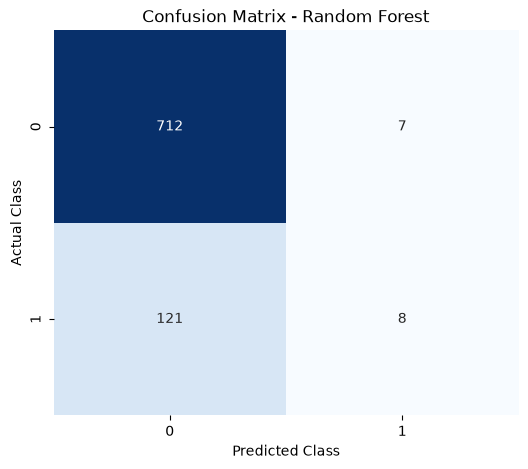

In [9]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Random Forest")

plt.show()

The confusion matrix shows that the Random Forest model correctly classified 712 participants who did not develop coronary heart disease and 8 participants who developed the disease. However, the model misclassified 121 positive cases as negative, resulting in a large number of false negatives. This finding explains the low recall observed for the positive class and indicates that the baseline Random Forest model is biased towards predicting the majority class. Although the model performs well in identifying negative cases, its ability to detect participants at risk of developing coronary heart disease remains limited.

### **Classification Report**

The classification report provides a detailed summary of the Random Forest model's performance for each class by presenting precision, recall, F1-score, and support. These metrics offer a more comprehensive evaluation of the classifier, particularly when dealing with imbalanced datasets.

In [10]:
# Display the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.99      0.92       719
           1       0.53      0.06      0.11       129

    accuracy                           0.85       848
   macro avg       0.69      0.53      0.51       848
weighted avg       0.81      0.85      0.79       848



The classification report indicates that the Random Forest model performs substantially better on the majority class than on the minority class. For participants who did not develop coronary heart disease, the model achieved high precision, recall, and F1-score, demonstrating strong predictive performance. In contrast, the positive class exhibited a precision of 0.53, recall of 0.06, and an F1-score of 0.11, indicating that only a small proportion of participants who developed coronary heart disease were correctly identified. These findings further confirm that the baseline Random Forest model is affected by the class imbalance present in the dataset and has limited ability to detect minority class instances.

### **Receiver Operating Characteristic (ROC) Curve**

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate (1 − specificity) across different classification thresholds. The Area Under the Curve (ROC-AUC) provides an overall measure of the model's ability to distinguish between participants who developed coronary heart disease and those who did not.

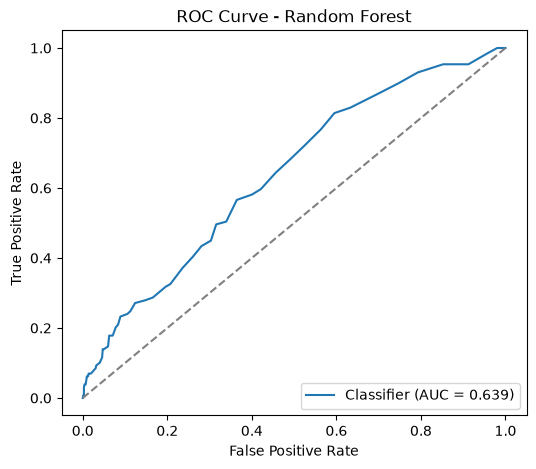

In [11]:
# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Classifier (AUC = {roc_auc:.3f})"
)

# Plot the reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Customize the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")

plt.show()

The ROC curve demonstrates the discriminative ability of the Random Forest model across different classification thresholds. The model achieved an ROC-AUC score of 0.639, indicating a modest ability to distinguish between participants who developed coronary heart disease and those who did not. Although the model correctly classified most negative cases, its low recall indicates that many positive cases were missed when using the default classification threshold. Consequently, while the baseline Random Forest model provides a useful benchmark, its predictive performance can be improved through hyperparameter tuning and class imbalance handling techniques, which will be explored in subsequent stages of this study.

### **Feature Importance**

Random Forest estimates the relative importance of predictor variables based on their contribution to reducing impurity across the ensemble of decision trees. Examining feature importance provides insight into the variables that most strongly influence the model's predictions.

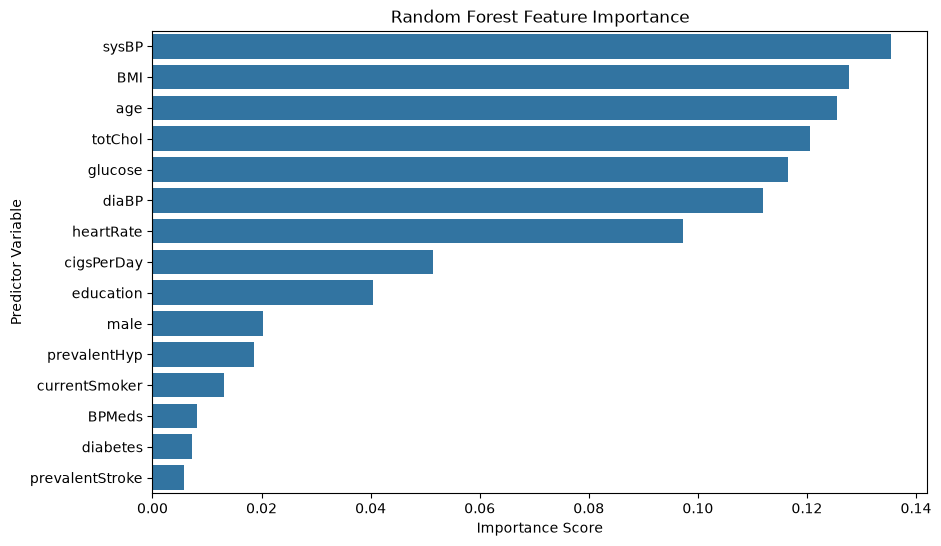

sysBP              0.135340
BMI                0.127713
age                0.125592
totChol            0.120585
glucose            0.116446
diaBP              0.111927
heartRate          0.097225
cigsPerDay         0.051521
education          0.040461
male               0.020272
prevalentHyp       0.018585
currentSmoker      0.013167
BPMeds             0.008180
diabetes           0.007181
prevalentStroke    0.005805
dtype: float64

In [14]:
# Extract feature importance scores from the trained Random Forest model
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

# Sort the features from most important to least important
feature_importance = feature_importance.sort_values(ascending=False)

# Plot the feature importance scores
plt.figure(figsize=(10, 6))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

# Customize the plot
plt.xlabel("Importance Score")
plt.ylabel("Predictor Variable")
plt.title("Random Forest Feature Importance")

# Display the plot
plt.show()

# Display the numerical importance scores
feature_importance

The feature importance analysis indicates that systolic blood pressure (`sysBP`) was the most influential predictor of ten-year coronary heart disease, followed by body mass index (`BMI`), age, total cholesterol (`totChol`), glucose, and diastolic blood pressure (`diaBP`). Variables such as prevalent stroke, diabetes, blood pressure medication use, and current smoking contributed relatively little to the model's predictions. Overall, the importance ranking highlights that cardiovascular risk factors, particularly blood pressure, body composition, age, and cholesterol, played the greatest role in the Random Forest model's prediction of coronary heart disease.

### **Model Persistence**

The trained Random Forest model is saved for future use in model comparison, further evaluation, and deployment. Saving the fitted model eliminates the need to retrain it whenever predictions or additional analyses are required.

In [15]:
# Save the trained Random Forest model
joblib.dump(
    rf,
    "../models/random_forest.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


The trained Random Forest model was successfully saved to the models directory. The saved model can be reloaded later for prediction, model comparison, or deployment without repeating the training process.

## **Conclusion**

This notebook developed and evaluated a baseline Random Forest model for predicting ten-year coronary heart disease using the Framingham dataset. The model was trained using the unscaled training dataset and evaluated using multiple performance metrics, including accuracy, precision, recall, F1-score, the confusion matrix, the ROC curve, and feature importance analysis.

The baseline Random Forest model achieved good overall accuracy but demonstrated limited ability to identify participants who developed coronary heart disease, as reflected by its low recall and modest ROC-AUC score. The feature importance analysis identified systolic blood pressure, body mass index, age, total cholesterol, glucose, and diastolic blood pressure as the most influential predictors of coronary heart disease, highlighting clinically relevant cardiovascular risk factors.

Overall, the baseline Random Forest model provides an important benchmark for subsequent modelling experiments. In the following stages of this study, hyperparameter tuning and class imbalance handling techniques will be investigated to improve the model's ability to detect positive coronary heart disease cases while maintaining strong overall predictive performance.

**Next Phase:** XGBoost